# Task 1: Understand the Business Problem

Before building the model, read the business plan carefully and write a short explanation answering:

- What is the business about?
- What problem is the business trying to solve?
- What decision can machine learning help the business make?
- What is the target variable in the dataset?
- What are the input features?
- Why is this prediction useful for the business?

# Business Problem and Dataset Overview: SalesBoost CRM Analytics

## 1. What is the business about?

SalesBoost CRM Analytics is a B2B software company that sells a cloud-based CRM and sales automation platform to organizations across Canada. It acquires leads through multiple channels: LinkedIn, Google, webinars, referrals, trade shows, email campaigns, and organic web traffic and needs to decide how to act on those leads efficiently.

## 2. What problem is the business trying to solve?

Sales representatives currently spend equal time on all leads, regardless of purchase intent. This creates three costly issues: 
- High-potential leads may not receive fast follow-up,
- Sales reps waste time on unlikely buyers, and
- Managers lack a consistent, data-backed way to justify prioritization decisions.

SalesBoost wants a smarter, data-driven approach to lead qualification.

## 3. What decision can machine learning help the business make?

A Decision Tree classifier can predict whether a given lead will become a won deal. Based on that prediction, the business can route leads into different workflows, fast follow-up and senior rep assignment for likely wins, versus nurturing campaigns or lower-priority queues for unlikely ones. The model serves as a decision-support tool, not a replacement for human judgment.

## 4. What is the target variable in the dataset?

The target variable is `Deal_Won`, a binary classification label with two values: Yes (the lead became a paying customer) or No (it did not).

## 5. What are the input features?

The features fall into four groups: 

| Feature Group | Examples | 
|---|---| 
| **Lead & company profile** | `Lead_Source`, `Industry`, `Region`, `Company_Size`, `Employee_Count`, `Annual_Revenue_Estimate`, `Use_Case` | 
| **Engagement behavior** | `Website_Visits_30D`, `Email_Open_Rate`, `Demo_Requested` | 
| **Sales process activity** | `Sales_Calls_Count`, `Proposal_Sent`, `Budget_Confirmed`, `Decision_Maker_Involved`, `Competitor_Considered` | 
| **Commercial & pipeline** | `Discount_Offered_Percent`, `Days_In_Pipeline`, `Estimated_Deal_Value`, `Lead_Score`, `Sales_Rep` |

## 6. Why is this prediction useful for the business?

Sales time is a finite resource. Knowing in advance which leads are likely to convert allows managers to allocate rep time, tailor follow-up urgency, and improve conversion rates without hiring more staff. Beyond predictions, the model's feature importance output can reveal which factors (e.g., budget confirmation, decision-maker involvement, demo requests) most strongly drive wins offering strategic insight for marketing investment and sales training as well.

# Task 2: Prepare the Data

In your notebook, complete the following steps:

- Load the dataset
- Inspect the dataset
- Check the number of rows and columns
- Check data types
- Check missing values
- Check duplicate rows
- Clean the dataset if needed
- Separate features and target variable
- Handle categorical and numerical variables if needed
- Split the data into training and testing sets

In [7]:
# Import pandas library to work with datasets
import pandas as pd

# Import display function to show tables clearly in Jupyter Notebook
from IPython.display import display

# Store the CSV file name in a variable
file_path = "salesboost_b2b_deal_win_dataset.csv"

# Read the CSV file and load it into a pandas DataFrame
df = pd.read_csv(file_path)

# Print a message to confirm that the dataset has been loaded successfully
print("Dataset loaded successfully!")

# Print the number of rows and columns in the dataset
print("Dataset shape:", df.shape)

# Display the first five rows of the dataset
display(df.head())

Dataset loaded successfully!
Dataset shape: (264, 23)


,Lead_ID,Lead_Date,Lead_Source,Industry,Region,Company_Size,Employee_Count,Annual_Revenue_Estimate,Use_Case,Website_Visits_30D,...,Proposal_Sent,Budget_Confirmed,Decision_Maker_Involved,Competitor_Considered,Discount_Offered_Percent,Days_In_Pipeline,Estimated_Deal_Value,Lead_Score,Sales_Rep,Deal_Won
0,L0001,2026-04-08,Webinar,Retail,Ontario,Small,13,"$2,185,044",Marketing Automation,1.0,...,No,Yes,No,No,0.4,29,"$1,500",40,Rep D,No
1,L0002,2026-02-04,Google Search,Retail,Ontario,Large,873,"$17,882,397",Marketing Automation,11.0,...,Yes,Yes,Yes,Yes,17.0,41,"$60,925",79,Rep C,Yes
2,L0003,2026-02-01,Email Campaign,Technology,Ontario,Medium,235,"$9,671,758",Customer Analytics,14.0,...,No,No,Yes,No,11.6,1,"$16,408",66,Rep C,Yes
3,L0004,2026-04-09,Email Campaign,Manufacturing,Alberta,Medium,88,"$12,313,739",Customer Analytics,18.0,...,No,Yes,No,No,5.2,20,"$8,580",43,Rep C,No
4,L0005,2026-01-31,Email Campaign,Retail,Quebec,Medium,220,"$11,200,203",Workflow Automation,10.0,...,No,No,No,No,10.1,31,"$22,890",32,Rep E,No


In [8]:
# Print a title for this output
print("Dataset Shape")

# Print a separator line to make the output clear
print("-" * 50)

# Show the number of rows and columns in the dataset
print(df.shape)

Dataset Shape
--------------------------------------------------
(264, 23)


In [9]:
# Print a title for this output
print("First Five Rows of the Dataset")

# Print a separator line to make the output clear
print("-" * 50)

# Display the first five rows of the dataset
display(df.head())

First Five Rows of the Dataset
--------------------------------------------------


,Lead_ID,Lead_Date,Lead_Source,Industry,Region,Company_Size,Employee_Count,Annual_Revenue_Estimate,Use_Case,Website_Visits_30D,...,Proposal_Sent,Budget_Confirmed,Decision_Maker_Involved,Competitor_Considered,Discount_Offered_Percent,Days_In_Pipeline,Estimated_Deal_Value,Lead_Score,Sales_Rep,Deal_Won
0,L0001,2026-04-08,Webinar,Retail,Ontario,Small,13,"$2,185,044",Marketing Automation,1.0,...,No,Yes,No,No,0.4,29,"$1,500",40,Rep D,No
1,L0002,2026-02-04,Google Search,Retail,Ontario,Large,873,"$17,882,397",Marketing Automation,11.0,...,Yes,Yes,Yes,Yes,17.0,41,"$60,925",79,Rep C,Yes
2,L0003,2026-02-01,Email Campaign,Technology,Ontario,Medium,235,"$9,671,758",Customer Analytics,14.0,...,No,No,Yes,No,11.6,1,"$16,408",66,Rep C,Yes
3,L0004,2026-04-09,Email Campaign,Manufacturing,Alberta,Medium,88,"$12,313,739",Customer Analytics,18.0,...,No,Yes,No,No,5.2,20,"$8,580",43,Rep C,No
4,L0005,2026-01-31,Email Campaign,Retail,Quebec,Medium,220,"$11,200,203",Workflow Automation,10.0,...,No,No,No,No,10.1,31,"$22,890",32,Rep E,No


In [10]:
# Print a title for this output
print("Last Five Rows of the Dataset")

# Print a separator line to make the output clear
print("-" * 50)

# Display the last five rows of the dataset
display(df.tail())

Last Five Rows of the Dataset
--------------------------------------------------


,Lead_ID,Lead_Date,Lead_Source,Industry,Region,Company_Size,Employee_Count,Annual_Revenue_Estimate,Use_Case,Website_Visits_30D,...,Proposal_Sent,Budget_Confirmed,Decision_Maker_Involved,Competitor_Considered,Discount_Offered_Percent,Days_In_Pipeline,Estimated_Deal_Value,Lead_Score,Sales_Rep,Deal_Won
259,L0260,2026-02-21,Email Campaign,Education,Prairies,Medium,72,"$9,043,749",Workflow Automation,11.0,...,Yes,Yes,Yes,No,1.7,21,"$3,854",70,Rep A,Yes
260,L0013,2026-01-14,Organic Website,Professional Services,Ontario,Small,55,"$2,064,248",Marketing Automation,18.0,...,Yes,Yes,No,No,0.0,37,"$3,153",73,Rep D,Yes
261,L0059,2026-04-08,Email Campaign,Professional Services,British Columbia,Medium,233,"$3,729,561",Marketing Automation,19.0,...,Yes,Yes,No,No,6.7,8,"$23,689",75,Rep D,Yes
262,L0144,2026-03-15,Google Search,Technology,Ontario,Medium,131,"$14,565,887",CRM Automation,19.0,...,Yes,Yes,Yes,Yes,20.5,48,"$10,875",64,Rep E,Yes
263,L0202,2026-01-29,LinkedIn Ads,Education,Ontario,Medium,242,"$12,407,553",Workflow Automation,14.0,...,Yes,No,No,Yes,12.0,26,"$21,736",49,Rep C,No


In [11]:
# Print a title for this output
print("Column Names")

# Print a separator line to make the output clear
print("-" * 50)

# Display all column names as a list
print(df.columns.tolist())

Column Names
--------------------------------------------------
['Lead_ID', 'Lead_Date', 'Lead_Source', 'Industry', 'Region', 'Company_Size', 'Employee_Count', 'Annual_Revenue_Estimate', 'Use_Case', 'Website_Visits_30D', 'Email_Open_Rate', 'Sales_Calls_Count', 'Demo_Requested', 'Proposal_Sent', 'Budget_Confirmed', 'Decision_Maker_Involved', 'Competitor_Considered', 'Discount_Offered_Percent', 'Days_In_Pipeline', 'Estimated_Deal_Value', 'Lead_Score', 'Sales_Rep', 'Deal_Won']


In [12]:
# Print a title for this output
print("Dataset Information")

# Print a separator line to make the output clear
print("-" * 50)

# Show column names, non-null values, and data types
df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Lead_ID                   264 non-null    object 
 1   Lead_Date                 264 non-null    object 
 2   Lead_Source               261 non-null    object 
 3   Industry                  260 non-null    object 
 4   Region                    264 non-null    object 
 5   Company_Size              264 non-null    object 
 6   Employee_Count            264 non-null    int64  
 7   Annual_Revenue_Estimate   257 non-null    object 
 8   Use_Case                  264 non-null    object 
 9   Website_Visits_30D        260 non-null    float64
 10  Email_Open_Rate           258 non-null    object 
 11  Sales_Calls_Count         264 non-null    int64  
 12  Demo_Requested            264 non-null    object 

In [13]:
# Print a title for this output
print("Data Types of Each Column")

# Print a separator line to make the output clear
print("-" * 50)

# Display the data type of each column
display(df.dtypes)

Data Types of Each Column
--------------------------------------------------


Lead_ID                      object
Lead_Date                    object
Lead_Source                  object
Industry                     object
Region                       object
Company_Size                 object
Employee_Count                int64
Annual_Revenue_Estimate      object
Use_Case                     object
Website_Visits_30D          float64
Email_Open_Rate              object
Sales_Calls_Count             int64
Demo_Requested               object
Proposal_Sent                object
Budget_Confirmed             object
Decision_Maker_Involved      object
Competitor_Considered        object
Discount_Offered_Percent    float64
Days_In_Pipeline              int64
Estimated_Deal_Value         object
Lead_Score                    int64
Sales_Rep                    object
Deal_Won                     object
dtype: object

In [14]:
# Print a title for this output
print("Missing Values in Each Column")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values in each column
missing_values = df.isnull().sum()

# Display the number of missing values for each column
display(missing_values)

Missing Values in Each Column
--------------------------------------------------


Lead_ID                     0
Lead_Date                   0
Lead_Source                 3
Industry                    4
Region                      0
Company_Size                0
Employee_Count              0
Annual_Revenue_Estimate     7
Use_Case                    0
Website_Visits_30D          4
Email_Open_Rate             6
Sales_Calls_Count           0
Demo_Requested              0
Proposal_Sent               0
Budget_Confirmed            3
Decision_Maker_Involved     0
Competitor_Considered       0
Discount_Offered_Percent    0
Days_In_Pipeline            0
Estimated_Deal_Value        0
Lead_Score                  0
Sales_Rep                   0
Deal_Won                    0
dtype: int64

In [15]:
# Print a title for this output
print("Number of Duplicate Rows")

# Print a separator line to make the output clear
print("-" * 50)

# Count the number of duplicate rows in the dataset
duplicate_rows = df.duplicated().sum()

# Display the number of duplicate rows
print(duplicate_rows)

Number of Duplicate Rows
--------------------------------------------------
4


In [16]:
# Print a title for this output
print("Summary Statistics for Numerical Columns")

# Print a separator line to make the output clear
print("-" * 50)

# Display summary statistics for numerical columns
display(df.describe())

Summary Statistics for Numerical Columns
--------------------------------------------------


,Employee_Count,Website_Visits_30D,Sales_Calls_Count,Discount_Offered_Percent,Days_In_Pipeline,Lead_Score
count,264.000000,260.000000,264.000000,264.000000,264.000000,264.000000
mean,517.401515,13.623077,2.458333,10.634848,29.359848,59.458333
std,1179.069559,8.100494,1.663225,6.531241,14.590847,19.387929
min,8.000000,0.000000,0.000000,0.000000,1.000000,5.000000
25%,43.750000,8.000000,1.000000,5.600000,19.000000,47.000000
50%,108.500000,13.000000,2.000000,10.450000,28.500000,59.500000
75%,307.750000,19.000000,4.000000,14.850000,38.000000,74.000000
max,6893.000000,35.000000,8.000000,30.700000,83.000000,98.000000


# Data Cleaning
Before training a machine learning model, we need to clean the dataset.

In this step, we create a copy of the original dataset and remove duplicate rows.

Duplicate rows can affect the model because repeated records may give extra weight to the same information.

At this stage, we do not handle missing values yet. Missing values will be handled in the next step.

In [17]:
# Create a copy of the original dataset
df_clean = df.copy()

# Print a message to confirm that the copy was created
print("A copy of the dataset has been created.")

# Show the shape of the original dataset
print("Original dataset shape:", df.shape)

# Show the shape of the copied dataset
print("Copied dataset shape:", df_clean.shape)

A copy of the dataset has been created.
Original dataset shape: (264, 23)
Copied dataset shape: (264, 23)


In [18]:
# Count the number of duplicate rows before cleaning
duplicates_before = df_clean.duplicated().sum()

# Print the number of duplicate rows before cleaning
print("Number of duplicate rows before cleaning:", duplicates_before)

Number of duplicate rows before cleaning: 4


In [19]:
# Remove duplicate rows from the dataset
df_clean = df_clean.drop_duplicates()

# Print a message to confirm that duplicate rows were removed
print("Duplicate rows have been removed.")

Duplicate rows have been removed.


In [20]:
# Show the shape of the dataset after removing duplicate rows
print("Dataset shape after removing duplicates:", df_clean.shape)

# Count the number of duplicate rows after cleaning
duplicates_after = df_clean.duplicated().sum()

# Print the number of duplicate rows after cleaning
print("Number of duplicate rows after cleaning:", duplicates_after)

Dataset shape after removing duplicates: (260, 23)
Number of duplicate rows after cleaning: 0


In [21]:
# Display the first five rows of the cleaned dataset
display(df_clean.head())

,Lead_ID,Lead_Date,Lead_Source,Industry,Region,Company_Size,Employee_Count,Annual_Revenue_Estimate,Use_Case,Website_Visits_30D,...,Proposal_Sent,Budget_Confirmed,Decision_Maker_Involved,Competitor_Considered,Discount_Offered_Percent,Days_In_Pipeline,Estimated_Deal_Value,Lead_Score,Sales_Rep,Deal_Won
0,L0001,2026-04-08,Webinar,Retail,Ontario,Small,13,"$2,185,044",Marketing Automation,1.0,...,No,Yes,No,No,0.4,29,"$1,500",40,Rep D,No
1,L0002,2026-02-04,Google Search,Retail,Ontario,Large,873,"$17,882,397",Marketing Automation,11.0,...,Yes,Yes,Yes,Yes,17.0,41,"$60,925",79,Rep C,Yes
2,L0003,2026-02-01,Email Campaign,Technology,Ontario,Medium,235,"$9,671,758",Customer Analytics,14.0,...,No,No,Yes,No,11.6,1,"$16,408",66,Rep C,Yes
3,L0004,2026-04-09,Email Campaign,Manufacturing,Alberta,Medium,88,"$12,313,739",Customer Analytics,18.0,...,No,Yes,No,No,5.2,20,"$8,580",43,Rep C,No
4,L0005,2026-01-31,Email Campaign,Retail,Quebec,Medium,220,"$11,200,203",Workflow Automation,10.0,...,No,No,No,No,10.1,31,"$22,890",32,Rep E,No


In [139]:
# Remove $ sign and commas, then convert Annual_Revenue_Estimate to float
df_clean["Annual_Revenue_Estimate"] = (
    df_clean["Annual_Revenue_Estimate"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

# Remove % sign, then convert Email_Open_Rate to float
df_clean["Email_Open_Rate"] = (
    df_clean["Email_Open_Rate"]
    .replace("%", "", regex=True)
    .astype(float)
)

# Remove $ sign and commas, then convert Estimated_Deal_Value to float
df_clean["Estimated_Deal_Value"] = (
    df_clean["Estimated_Deal_Value"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

# Display data types after cleaning
print("Data types after cleaning:")
print(df_clean.dtypes)

Data types after cleaning:
Lead_ID                      object
Lead_Date                    object
Lead_Source                  object
Industry                     object
Region                       object
Company_Size                 object
Employee_Count                int64
Annual_Revenue_Estimate     float64
Use_Case                     object
Website_Visits_30D          float64
Email_Open_Rate             float64
Sales_Calls_Count             int64
Demo_Requested               object
Proposal_Sent                object
Budget_Confirmed             object
Decision_Maker_Involved      object
Competitor_Considered        object
Discount_Offered_Percent    float64
Days_In_Pipeline              int64
Estimated_Deal_Value        float64
Lead_Score                    int64
Sales_Rep                    object
Deal_Won                     object
dtype: object


# Handling Missing Values
In this step, we handle missing values in the cleaned dataset.

Missing values can cause errors during model training, because most machine learning algorithms cannot work with empty cells.

For numerical columns, we fill missing values using the median value of each column.

For categorical columns, we fill missing values using the most frequent value, also called the mode.

This helps us prepare a complete dataset for machine learning.

In [25]:
# Print a title for this output
print("Missing Values Before Handling")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values in each column before handling them
missing_values_before = df_clean.isnull().sum()

# Display missing values before handling
display(missing_values_before)

Missing Values Before Handling
--------------------------------------------------


Lead_ID                     0
Lead_Date                   0
Lead_Source                 3
Industry                    4
Region                      0
Company_Size                0
Employee_Count              0
Annual_Revenue_Estimate     7
Use_Case                    0
Website_Visits_30D          4
Email_Open_Rate             6
Sales_Calls_Count           0
Demo_Requested              0
Proposal_Sent               0
Budget_Confirmed            3
Decision_Maker_Involved     0
Competitor_Considered       0
Discount_Offered_Percent    0
Days_In_Pipeline            0
Estimated_Deal_Value        0
Lead_Score                  0
Sales_Rep                   0
Deal_Won                    0
dtype: int64

In [26]:
# Select numerical columns from the cleaned dataset
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Select categorical columns from the cleaned dataset
categorical_columns = df_clean.select_dtypes(include=["object"]).columns.tolist()

# Print numerical columns
print("Numerical columns:")

# Display numerical columns
print(numerical_columns)

# Print a separator line
print("-" * 50)

# Print categorical columns
print("Categorical columns:")

# Display categorical columns
print(categorical_columns)

Numerical columns:
['Employee_Count', 'Annual_Revenue_Estimate', 'Website_Visits_30D', 'Email_Open_Rate', 'Sales_Calls_Count', 'Discount_Offered_Percent', 'Days_In_Pipeline', 'Estimated_Deal_Value', 'Lead_Score']
--------------------------------------------------
Categorical columns:
['Lead_ID', 'Lead_Date', 'Lead_Source', 'Industry', 'Region', 'Company_Size', 'Use_Case', 'Demo_Requested', 'Proposal_Sent', 'Budget_Confirmed', 'Decision_Maker_Involved', 'Competitor_Considered', 'Sales_Rep', 'Deal_Won']


In [27]:
# Loop through each numerical column
for column in numerical_columns:
    
    # Calculate the median value of the current numerical column
    median_value = df_clean[column].median()
    
    # Fill missing values in the current column with the median value
    df_clean[column] = df_clean[column].fillna(median_value)

# Print a message after handling numerical missing values
print("Missing values in numerical columns have been filled with the median.")

Missing values in numerical columns have been filled with the median.


In [28]:
# Loop through each categorical column
for column in categorical_columns:
    
    # Calculate the most frequent value of the current categorical column
    mode_value = df_clean[column].mode()[0]
    
    # Fill missing values in the current column with the most frequent value
    df_clean[column] = df_clean[column].fillna(mode_value)

# Print a message after handling categorical missing values
print("Missing values in categorical columns have been filled with the mode.")

Missing values in categorical columns have been filled with the mode.


In [29]:
# Print a title for this output
print("Missing Values After Handling")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values after handling them
missing_values_after = df_clean.isnull().sum()

# Display missing values after handling
display(missing_values_after)

Missing Values After Handling
--------------------------------------------------


Lead_ID                     0
Lead_Date                   0
Lead_Source                 0
Industry                    0
Region                      0
Company_Size                0
Employee_Count              0
Annual_Revenue_Estimate     0
Use_Case                    0
Website_Visits_30D          0
Email_Open_Rate             0
Sales_Calls_Count           0
Demo_Requested              0
Proposal_Sent               0
Budget_Confirmed            0
Decision_Maker_Involved     0
Competitor_Considered       0
Discount_Offered_Percent    0
Days_In_Pipeline            0
Estimated_Deal_Value        0
Lead_Score                  0
Sales_Rep                   0
Deal_Won                    0
dtype: int64

In [30]:
# Print the shape of the cleaned dataset after handling missing values
print("Dataset shape after handling missing values:", df_clean.shape)

# Display the first five rows of the cleaned dataset
display(df_clean.head())

Dataset shape after handling missing values: (260, 23)


,Lead_ID,Lead_Date,Lead_Source,Industry,Region,Company_Size,Employee_Count,Annual_Revenue_Estimate,Use_Case,Website_Visits_30D,...,Proposal_Sent,Budget_Confirmed,Decision_Maker_Involved,Competitor_Considered,Discount_Offered_Percent,Days_In_Pipeline,Estimated_Deal_Value,Lead_Score,Sales_Rep,Deal_Won
0,L0001,2026-04-08,Webinar,Retail,Ontario,Small,13,2185044.0,Marketing Automation,1.0,...,No,Yes,No,No,0.4,29,1500.0,40,Rep D,No
1,L0002,2026-02-04,Google Search,Retail,Ontario,Large,873,17882397.0,Marketing Automation,11.0,...,Yes,Yes,Yes,Yes,17.0,41,60925.0,79,Rep C,Yes
2,L0003,2026-02-01,Email Campaign,Technology,Ontario,Medium,235,9671758.0,Customer Analytics,14.0,...,No,No,Yes,No,11.6,1,16408.0,66,Rep C,Yes
3,L0004,2026-04-09,Email Campaign,Manufacturing,Alberta,Medium,88,12313739.0,Customer Analytics,18.0,...,No,Yes,No,No,5.2,20,8580.0,43,Rep C,No
4,L0005,2026-01-31,Email Campaign,Retail,Quebec,Medium,220,11200203.0,Workflow Automation,10.0,...,No,No,No,No,10.1,31,22890.0,32,Rep E,No


# Understanding Features and Target Variable
In this step, we identify the input features and the target variable of the dataset.

The target variable is the column that we want the machine learning model to predict.

In this dataset, the target variable is Deal_Won. 

The features are the columns that help the model make the prediction.

In [31]:
# Store the target column name in a variable
target_column = "Deal_Won"

# Print the target variable name
print("Target variable:")

# Display the target column name
print(target_column)

Target variable:
Deal_Won


In [37]:
# Print a title for the target values
print("Target variable values:")

# Print a separator line
print("-" * 50)

# Display the unique values in the target column
print(df_clean[target_column].unique())

Target variable values:
--------------------------------------------------
['No' 'Yes']


In [38]:
# Print a title for the target class distribution
print("Target class distribution:")

# Print a separator line
print("-" * 50)

# Count how many customers are in each target class
target_counts = df_clean[target_column].value_counts()

# Display the target class counts
display(target_counts)

Target class distribution:
--------------------------------------------------


Deal_Won
Yes    136
No     124
Name: count, dtype: int64

In [71]:
# Create a list of feature columns by removing the target column and Lead_ID column
feature_columns = df_clean.drop(columns=[target_column, "Lead_ID", "Lead_Date"]).columns.tolist()

# Print a title for the feature columns
print("Feature columns:")

# Print a separator line
print("-" * 50)

# Display the feature columns
print(feature_columns)

Feature columns:
--------------------------------------------------
['Lead_Source', 'Industry', 'Region', 'Company_Size', 'Employee_Count', 'Annual_Revenue_Estimate', 'Use_Case', 'Website_Visits_30D', 'Email_Open_Rate', 'Sales_Calls_Count', 'Demo_Requested', 'Proposal_Sent', 'Budget_Confirmed', 'Decision_Maker_Involved', 'Competitor_Considered', 'Discount_Offered_Percent', 'Days_In_Pipeline', 'Estimated_Deal_Value', 'Lead_Score', 'Sales_Rep']


# Handling Categorical and Numerical Variables
In this step, we identify numerical and categorical variables in the dataset.

This step is important because machine learning models need numerical input.

Later, we will convert categorical variables into numerical format during preprocessing.

In [72]:
# Select numerical columns from the cleaned dataset
numerical_features = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Print a title for numerical features
print("Numerical feature columns:")

# Print a separator line
print("-" * 50)

# Display numerical feature columns
print(numerical_features)

Numerical feature columns:
--------------------------------------------------
['Employee_Count', 'Annual_Revenue_Estimate', 'Website_Visits_30D', 'Email_Open_Rate', 'Sales_Calls_Count', 'Discount_Offered_Percent', 'Days_In_Pipeline', 'Estimated_Deal_Value', 'Lead_Score']


In [73]:
# Select categorical columns from the cleaned dataset
categorical_features = df_clean.select_dtypes(include=["object"]).columns.tolist()

# Remove the target column from categorical features if it is included
if target_column in categorical_features:
    categorical_features.remove(target_column) 
   
# Remove Lead_ID 
if "Lead_ID" in categorical_features:
    categorical_features.remove("Lead_ID")

# Remove Lead_Date 
if "Lead_Date" in categorical_features:
    categorical_features.remove("Lead_Date")
 
# Print a title for categorical features
print("Categorical feature columns:")

# Print a separator line
print("-" * 50)

# Display categorical feature columns
print(categorical_features)

Categorical feature columns:
--------------------------------------------------
['Lead_Source', 'Industry', 'Region', 'Company_Size', 'Use_Case', 'Demo_Requested', 'Proposal_Sent', 'Budget_Confirmed', 'Decision_Maker_Involved', 'Competitor_Considered', 'Sales_Rep']


In [74]:
# Count the number of numerical features
num_count = len(numerical_features)

# Count the number of categorical features
cat_count = len(categorical_features)

# Print the number of numerical features
print("Number of numerical features:", num_count)

# Print the number of categorical features
print("Number of categorical features:", cat_count)

Number of numerical features: 9
Number of categorical features: 11


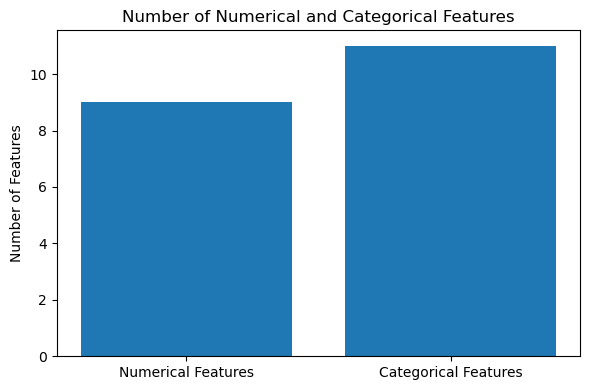

In [75]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Create labels for the chart
feature_type_labels = ["Numerical Features", "Categorical Features"]

# Create values for the chart
feature_type_counts = [num_count, cat_count]

# Create a figure for the chart
plt.figure(figsize=(6, 4))

# Create a bar chart
plt.bar(feature_type_labels, feature_type_counts)

# Add a chart title
plt.title("Number of Numerical and Categorical Features")

# Add a label to the y-axis
plt.ylabel("Number of Features")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [76]:
# Print a title for unique values
print("Unique values in categorical features")

# Print a separator line
print("-" * 50)

# Loop through each categorical feature
for column in categorical_features:
    
    # Print the column name
    print("Column:", column)
    
    # Print the unique values in the column
    print(df_clean[column].unique())
    
    # Print a separator line
    print("-" * 50)

Unique values in categorical features
--------------------------------------------------
Column: Lead_Source
['Webinar' 'Google Search' 'Email Campaign' 'LinkedIn Ads' 'Referral'
 'Organic Website' 'Trade Show']
--------------------------------------------------
Column: Industry
['Retail' 'Technology' 'Manufacturing' 'Hospitality' 'Healthcare'
 'Professional Services' 'Education' 'Finance']
--------------------------------------------------
Column: Region
['Ontario' 'Alberta' 'Quebec' 'Prairies' 'British Columbia'
 'Atlantic Canada']
--------------------------------------------------
Column: Company_Size
['Small' 'Large' 'Medium' 'Enterprise']
--------------------------------------------------
Column: Use_Case
['Marketing Automation' 'Customer Analytics' 'Workflow Automation'
 'CRM Automation' 'Sales Forecasting']
--------------------------------------------------
Column: Demo_Requested
['No' 'Yes']
--------------------------------------------------
Column: Proposal_Sent
['No' 'Yes']
-

In [77]:
# Count unique values for each categorical feature
categorical_unique_counts = df_clean[categorical_features].nunique()

# Print a title
print("Number of unique values in each categorical feature:")

# Print a separator line
print("-" * 50)

# Display the number of unique values
display(categorical_unique_counts)

Number of unique values in each categorical feature:
--------------------------------------------------


Lead_Source                7
Industry                   8
Region                     6
Company_Size               4
Use_Case                   5
Demo_Requested             2
Proposal_Sent              2
Budget_Confirmed           2
Decision_Maker_Involved    2
Competitor_Considered      2
Sales_Rep                  5
dtype: int64

## Short Interpretation
The dataset contains both numerical and categorical features.

Numerical features can be used directly by many machine learning models, while categorical features must be converted into numerical format before training.

In the next steps, we will define X and y, split the data into training and testing sets, and then apply preprocessing to prepare the data for Decision Tree model.

# Defining X and y
In this step, we define the input features and the target variable for the machine learning model.

The input features are stored in X. These are the columns that the model uses to make predictions.

The target variable is stored in y. This is the column that the model tries to predict.

In [78]:
# Define the name of the target column
target_column = "Deal_Won"

# Print the target column name
print("Target column:")

# Display the target column
print(target_column)

Target column:
Deal_Won


In [79]:
# Create X by removing the target column from the dataset
X = df_clean.drop(columns=[target_column, "Lead_ID", "Lead_Date"])

# Create y by selecting only the target column
y = df_clean[target_column]

# Print a message to confirm that X and y have been created
print("X and y have been defined successfully.")

X and y have been defined successfully.


In [80]:
# Print the shape of X
print("Shape of X:")

# Display the number of rows and columns in X
print(X.shape)

# Print a separator line
print("-" * 50)

# Print the shape of y
print("Shape of y:")

# Display the number of rows in y
print(y.shape)

Shape of X:
(260, 20)
--------------------------------------------------
Shape of y:
(260,)


In [81]:
# Print a title for X
print("First five rows of X:")

# Print a separator line
print("-" * 50)

# Display the first five rows of X
display(X.head())

First five rows of X:
--------------------------------------------------


,Lead_Source,Industry,Region,Company_Size,Employee_Count,Annual_Revenue_Estimate,Use_Case,Website_Visits_30D,Email_Open_Rate,Sales_Calls_Count,Demo_Requested,Proposal_Sent,Budget_Confirmed,Decision_Maker_Involved,Competitor_Considered,Discount_Offered_Percent,Days_In_Pipeline,Estimated_Deal_Value,Lead_Score,Sales_Rep
0,Webinar,Retail,Ontario,Small,13,2185044.0,Marketing Automation,1.0,28.0,1,No,No,Yes,No,No,0.4,29,1500.0,40,Rep D
1,Google Search,Retail,Ontario,Large,873,17882397.0,Marketing Automation,11.0,21.0,5,Yes,Yes,Yes,Yes,Yes,17.0,41,60925.0,79,Rep C
2,Email Campaign,Technology,Ontario,Medium,235,9671758.0,Customer Analytics,14.0,35.0,1,Yes,No,No,Yes,No,11.6,1,16408.0,66,Rep C
3,Email Campaign,Manufacturing,Alberta,Medium,88,12313739.0,Customer Analytics,18.0,49.0,0,No,No,Yes,No,No,5.2,20,8580.0,43,Rep C
4,Email Campaign,Retail,Quebec,Medium,220,11200203.0,Workflow Automation,10.0,31.0,1,No,No,No,No,No,10.1,31,22890.0,32,Rep E


In [82]:
# Print a title for y
print("First five values of y:")

# Print a separator line
print("-" * 50)

# Display the first five values of y
display(y.head())

First five values of y:
--------------------------------------------------


0     No
1    Yes
2    Yes
3     No
4     No
Name: Deal_Won, dtype: object

In [83]:
# Count how many times each target class appears
target_distribution = y.value_counts()

# Print a title for the target distribution
print("Target class distribution:")

# Print a separator line
print("-" * 50)

# Display the target class distribution
display(target_distribution)

Target class distribution:
--------------------------------------------------


Deal_Won
Yes    136
No     124
Name: count, dtype: int64

## Short Interpretation
Now the dataset has been divided into X and y.

X contains the input features.

y contains the target variable, Deal_Won.

In the next step, we will split the data into training and testing sets.

# Train/Test Split
In this step, we split the dataset into training and testing sets.

The training set is used to teach the machine learning model.

The testing set is used to evaluate how well the model performs on new, unseen data.

In this notebook, we use 80% of the data for training and 20% of the data for testing.

We also use stratify=y to keep the same proportion of Yes and No values in both training and testing sets.

In [84]:
# Import train_test_split function from scikit-learn
from sklearn.model_selection import train_test_split

In [85]:
# Split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    
    # Use X as the input features
    X,
    
    # Use y as the target variable
    y,
    
    # Use 20% of the data for testing
    test_size=0.2,
    
    # Keep the same target class distribution in train and test sets
    stratify=y,
    
    # Use a fixed random state to make the result reproducible
    random_state=42
)

# Print a message to confirm that the data has been split
print("Data has been split into training and testing sets.")

Data has been split into training and testing sets.


In [86]:
# Print the shape of X_train
print("X_train shape:")

# Display the number of rows and columns in X_train
print(X_train.shape)

# Print a separator line
print("-" * 50)

# Print the shape of X_test
print("X_test shape:")

# Display the number of rows and columns in X_test
print(X_test.shape)

# Print a separator line
print("-" * 50)

# Print the shape of y_train
print("y_train shape:")

# Display the number of target values in y_train
print(y_train.shape)

# Print a separator line
print("-" * 50)

# Print the shape of y_test
print("y_test shape:")

# Display the number of target values in y_test
print(y_test.shape)

X_train shape:
(208, 20)
--------------------------------------------------
X_test shape:
(52, 20)
--------------------------------------------------
y_train shape:
(208,)
--------------------------------------------------
y_test shape:
(52,)


In [87]:
# Print a title for the training target distribution
print("Target distribution in training set:")

# Print a separator line
print("-" * 50)

# Count the number of Yes and No values in y_train
train_distribution = y_train.value_counts()

# Display the target distribution in the training set
display(train_distribution)

Target distribution in training set:
--------------------------------------------------


Deal_Won
Yes    109
No      99
Name: count, dtype: int64

In [88]:
# Print a title for the testing target distribution
print("Target distribution in testing set:")

# Print a separator line
print("-" * 50)

# Count the number of Yes and No values in y_test
test_distribution = y_test.value_counts()

# Display the target distribution in the testing set
display(test_distribution)

Target distribution in testing set:
--------------------------------------------------


Deal_Won
Yes    27
No     25
Name: count, dtype: int64

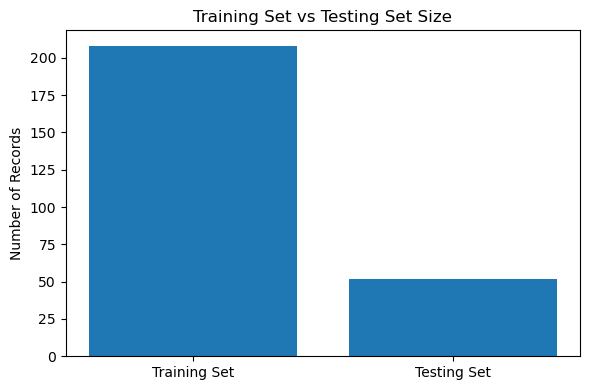

In [89]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Create labels for the chart
split_labels = ["Training Set", "Testing Set"]

# Create values for the chart
split_sizes = [len(X_train), len(X_test)]

# Create a figure for the chart
plt.figure(figsize=(6, 4))

# Create a bar chart for train and test size
plt.bar(split_labels, split_sizes)

# Add a title to the chart
plt.title("Training Set vs Testing Set Size")

# Add a label to the y-axis
plt.ylabel("Number of Records")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

## Short Interpretation
The dataset has now been divided into training and testing sets.

The training set will be used to train the Decision Tree model.

The testing set will be used to evaluate the models and compare their performance.

In the next step, we will preprocess the data so that categorical variables can be used by machine learning models.

# Preprocessing the Data
In this step, we preprocess the data before training machine learning models.

Machine learning models cannot directly work with categorical text values.

Therefore, we convert categorical variables into numerical format using One-Hot Encoding.

For Decision Tree model, feature scaling is usually not required because these models split the data based on decision rules.

We fit the preprocessing only on the training data and then apply it to the testing data. This helps prevent data leakage.

In [90]:
# Import ColumnTransformer to apply different preprocessing steps to different columns
from sklearn.compose import ColumnTransformer

# Import OneHotEncoder to convert categorical variables into numerical columns
from sklearn.preprocessing import OneHotEncoder

In [91]:
# Select numerical feature columns from X
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Select categorical feature columns from X
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Print numerical features
print("Numerical features:")
print(numerical_features)

# Print a separator line
print("-" * 50)

# Print categorical features
print("Categorical features:")
print(categorical_features)

Numerical features:
['Employee_Count', 'Annual_Revenue_Estimate', 'Website_Visits_30D', 'Email_Open_Rate', 'Sales_Calls_Count', 'Discount_Offered_Percent', 'Days_In_Pipeline', 'Estimated_Deal_Value', 'Lead_Score']
--------------------------------------------------
Categorical features:
['Lead_Source', 'Industry', 'Region', 'Company_Size', 'Use_Case', 'Demo_Requested', 'Proposal_Sent', 'Budget_Confirmed', 'Decision_Maker_Involved', 'Competitor_Considered', 'Sales_Rep']


In [93]:
# Create a one-hot encoder for categorical variables
# handle_unknown="ignore" prevents errors if new categories appear in the test set
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    
    # Define the transformations
    transformers=[
        
        # Apply one-hot encoding to categorical features
        ("categorical", encoder, categorical_features),
        
        # Keep numerical features unchanged
        ("numerical", "passthrough", numerical_features)
    ]
)

# Print a message to confirm that the preprocessor has been created
print("Preprocessor has been created successfully.")

Preprocessor has been created successfully.


In [94]:
# Fit the preprocessor on the training data and transform X_train
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the testing data using the same fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

# Print a message to confirm preprocessing is complete
print("Training and testing data have been preprocessed successfully.")

Training and testing data have been preprocessed successfully.


In [95]:
# Print the shape of the original X_train
print("Original X_train shape:")
print(X_train.shape)

# Print a separator line
print("-" * 50)

# Print the shape of the processed X_train
print("Processed X_train shape:")
print(X_train_processed.shape)

# Print a separator line
print("-" * 50)

# Print the shape of the original X_test
print("Original X_test shape:")
print(X_test.shape)

# Print a separator line
print("-" * 50)

# Print the shape of the processed X_test
print("Processed X_test shape:")
print(X_test_processed.shape)

Original X_train shape:
(208, 20)
--------------------------------------------------
Processed X_train shape:
(208, 54)
--------------------------------------------------
Original X_test shape:
(52, 20)
--------------------------------------------------
Processed X_test shape:
(52, 54)


In [96]:
# Get the new feature names created from categorical variables
encoded_categorical_features = preprocessor.named_transformers_["categorical"].get_feature_names_out(categorical_features)

# Combine encoded categorical feature names with numerical feature names
processed_feature_names = list(encoded_categorical_features) + numerical_features

# Print the total number of processed features
print("Number of processed features:", len(processed_feature_names))

# Print a separator line
print("-" * 50)

# Display the processed feature names
print(processed_feature_names)

Number of processed features: 54
--------------------------------------------------
['Lead_Source_Email Campaign', 'Lead_Source_Google Search', 'Lead_Source_LinkedIn Ads', 'Lead_Source_Organic Website', 'Lead_Source_Referral', 'Lead_Source_Trade Show', 'Lead_Source_Webinar', 'Industry_Education', 'Industry_Finance', 'Industry_Healthcare', 'Industry_Hospitality', 'Industry_Manufacturing', 'Industry_Professional Services', 'Industry_Retail', 'Industry_Technology', 'Region_Alberta', 'Region_Atlantic Canada', 'Region_British Columbia', 'Region_Ontario', 'Region_Prairies', 'Region_Quebec', 'Company_Size_Enterprise', 'Company_Size_Large', 'Company_Size_Medium', 'Company_Size_Small', 'Use_Case_CRM Automation', 'Use_Case_Customer Analytics', 'Use_Case_Marketing Automation', 'Use_Case_Sales Forecasting', 'Use_Case_Workflow Automation', 'Demo_Requested_No', 'Demo_Requested_Yes', 'Proposal_Sent_No', 'Proposal_Sent_Yes', 'Budget_Confirmed_No', 'Budget_Confirmed_Yes', 'Decision_Maker_Involved_No', 

In [97]:
# Convert processed training data into a DataFrame
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names,
    index=X_train.index
)

# Convert processed testing data into a DataFrame
X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=processed_feature_names,
    index=X_test.index
)

# Display the first five rows of the processed training data
display(X_train_processed_df.head())

,Lead_Source_Email Campaign,Lead_Source_Google Search,Lead_Source_LinkedIn Ads,Lead_Source_Organic Website,Lead_Source_Referral,Lead_Source_Trade Show,Lead_Source_Webinar,Industry_Education,Industry_Finance,Industry_Healthcare,...,Sales_Rep_Rep E,Employee_Count,Annual_Revenue_Estimate,Website_Visits_30D,Email_Open_Rate,Sales_Calls_Count,Discount_Offered_Percent,Days_In_Pipeline,Estimated_Deal_Value,Lead_Score
66,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,997.0,32699559.0,14.0,22.0,2.0,15.6,40.0,103124.0,66.0
244,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,63.0,336443.0,11.0,25.0,1.0,1.7,37.0,3895.0,33.0
9,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,34.0,1368365.0,0.0,26.0,2.0,15.6,23.0,2372.0,47.0
43,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,43.0,2210046.0,0.0,20.0,4.0,0.0,27.0,2224.0,49.0
73,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,26.0,1819576.0,8.0,38.0,3.0,14.8,18.0,1500.0,41.0


## Short Interpretation
The categorical features have now been converted into numerical format using One-Hot Encoding.

The numerical features were kept unchanged because Decision Tree model do not usually require feature scaling.

Now the dataset is ready for training tree-based machine learning models.

# Task 3: Train a Decision Tree Classification Model

Train one classification model:

- Decision Tree

After training the model, calculate the following:

- Confusion matrix
- Accuracy
- Precision
- Recall
- F1-score

You should also calculate:

- Training accuracy
- Testing accuracy

Then briefly explain whether the Decision Tree model may be overfitting.

# Training a Decision Tree Model
In this step, we train a Decision Tree classification model.

The model will learn patterns from the training data and use those patterns to predict whether a B2B lead will become a won deal.

We use the preprocessed training data because categorical variables have already been converted into numerical format.

For this example, we set `max_depth=4` to keep the tree simple and easier to understand.

In [98]:
# Import DecisionTreeClassifier from scikit-learn
from sklearn.tree import DecisionTreeClassifier

In [99]:
# Create a Decision Tree classification model
decision_tree_model = DecisionTreeClassifier(
    
    # Limit the depth of the tree to make it easier to understand
    max_depth=4,
    
    # Use a fixed random state to make the result reproducible
    random_state=42
)

# Print a message to confirm that the model has been created
print("Decision Tree model has been created.")

Decision Tree model has been created.


In [100]:
# Train the Decision Tree model using the preprocessed training data
decision_tree_model.fit(X_train_processed_df, y_train)

# Print a message to confirm that the model has been trained
print("Decision Tree model has been trained successfully.")

Decision Tree model has been trained successfully.


In [101]:
# Print the model information
print("Decision Tree Model Information")

# Print a separator line
print("-" * 50)

# Display the trained model
print(decision_tree_model)

Decision Tree Model Information
--------------------------------------------------
DecisionTreeClassifier(max_depth=4, random_state=42)


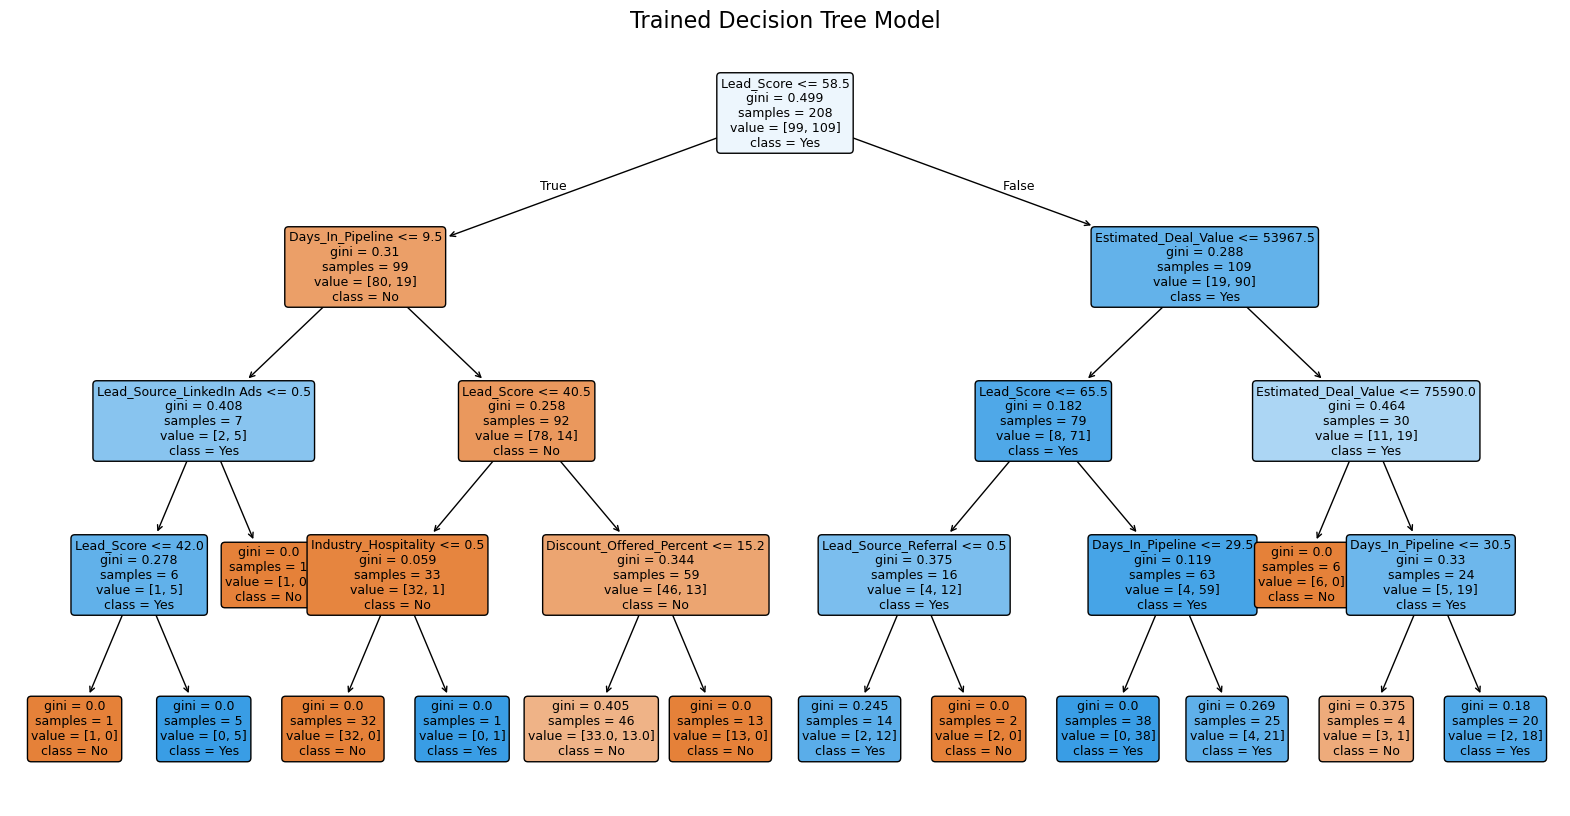

In [102]:
# Import matplotlib for creating the figure
import matplotlib.pyplot as plt

# Import plot_tree to visualize the Decision Tree
from sklearn.tree import plot_tree

# Create a large figure for the tree visualization
plt.figure(figsize=(20, 10))

# Plot the trained Decision Tree
plot_tree(
    
    # Use the trained Decision Tree model
    decision_tree_model,
    
    # Use feature names from the processed training data
    feature_names=X_train_processed_df.columns,
    
    # Show class names from the target variable
    class_names=decision_tree_model.classes_,
    
    # Fill the tree boxes to make the classes easier to distinguish
    filled=True,
    
    # Round the corners of the boxes
    rounded=True,
    
    # Set the font size
    fontsize=9
)

# Add a title to the figure
plt.title("Trained Decision Tree Model", fontsize=16)

# Display the figure
plt.show()

In [103]:
# Get the depth of the trained Decision Tree
tree_depth = decision_tree_model.get_depth()

# Get the number of leaf nodes in the trained Decision Tree
tree_leaves = decision_tree_model.get_n_leaves()

# Print the depth of the tree
print("Decision Tree depth:", tree_depth)

# Print the number of leaf nodes
print("Number of leaf nodes:", tree_leaves)

Decision Tree depth: 4
Number of leaf nodes: 14


# Evaluating the Decision Tree Model
After training the Decision Tree model, we need to evaluate its performance.

In this step, we use the trained Decision Tree model to make predictions on the testing set.

We also compare the predicted values with the actual values to see how the model performs.

In [104]:
# Use the trained Decision Tree model to predict the target values for the testing data
y_pred_dt = decision_tree_model.predict(X_test_processed_df)

# Print a message to confirm that predictions have been created
print("Decision Tree predictions have been created successfully.")

Decision Tree predictions have been created successfully.


In [105]:
# Create a DataFrame to compare actual and predicted values
dt_results = pd.DataFrame({
    
    # Store the actual values from the testing set
    "Actual": y_test.values,
    
    # Store the predicted values from the Decision Tree model
    "Predicted": y_pred_dt
})

# Print a title for the output
print("Actual vs Predicted Values")

# Print a separator line
print("-" * 50)

# Display the first ten actual and predicted values
display(dt_results.head(10))

Actual vs Predicted Values
--------------------------------------------------


,Actual,Predicted
0,No,Yes
1,Yes,No
2,No,No
3,No,No
4,No,No
5,Yes,Yes
6,Yes,No
7,No,No
8,No,Yes
9,No,Yes


In [106]:
# Import accuracy_score to calculate model accuracy
from sklearn.metrics import accuracy_score

# Calculate the accuracy of the Decision Tree model on the testing data
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

# Print the Decision Tree testing accuracy
print("Decision Tree Test Accuracy:")

# Display the accuracy value
print(dt_test_accuracy)

Decision Tree Test Accuracy:
0.75


In [107]:
# Predict the target values for the training data
y_train_pred_dt = decision_tree_model.predict(X_train_processed_df)

# Calculate the accuracy of the model on the training data
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)

# Calculate the accuracy of the model on the testing data
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

# Print the training accuracy
print("Decision Tree Training Accuracy:", dt_train_accuracy)

# Print the testing accuracy
print("Decision Tree Testing Accuracy:", dt_test_accuracy)

Decision Tree Training Accuracy: 0.8942307692307693
Decision Tree Testing Accuracy: 0.75


In [108]:
# Create a small table to compare training and testing accuracy
dt_accuracy_table = pd.DataFrame({
    
    # Store model evaluation type
    "Evaluation Set": ["Training Set", "Testing Set"],
    
    # Store accuracy values
    "Accuracy": [dt_train_accuracy, dt_test_accuracy]
})

# Display the accuracy comparison table
display(dt_accuracy_table)

,Evaluation Set,Accuracy
0,Training Set,0.894231
1,Testing Set,0.750000


In [109]:
# Count actual class values in the testing set
actual_counts = y_test.value_counts()

# Count predicted class values from the Decision Tree model
predicted_counts = pd.Series(y_pred_dt).value_counts()

# Create a comparison table for actual and predicted class counts
class_count_comparison = pd.DataFrame({
    
    # Store actual class counts
    "Actual": actual_counts,
    
    # Store predicted class counts
    "Predicted": predicted_counts
})

# Fill any missing values with zero
class_count_comparison = class_count_comparison.fillna(0)

# Display the comparison table
display(class_count_comparison)

,Actual,Predicted
No,25,28
Yes,27,24


<Figure size 700x400 with 0 Axes>

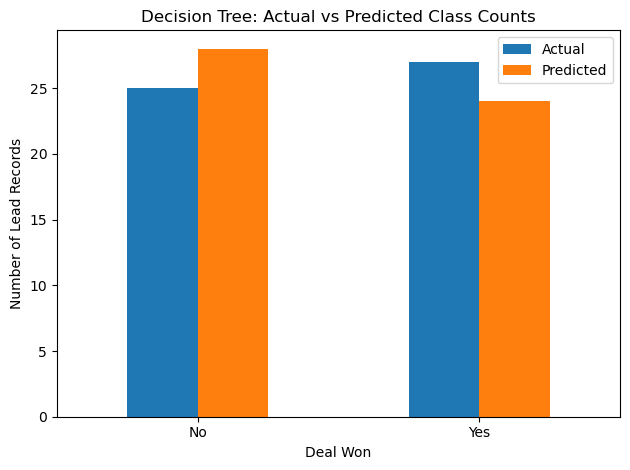

In [111]:
# Create a figure for actual vs predicted class counts
plt.figure(figsize=(7, 4))

# Create a bar chart for actual and predicted class counts
class_count_comparison.plot(kind="bar")

# Add a title to the chart
plt.title("Decision Tree: Actual vs Predicted Class Counts")

# Add a label to the x-axis
plt.xlabel("Deal Won")

# Add a label to the y-axis
plt.ylabel("Number of Lead Records")

# Rotate x-axis labels
plt.xticks(rotation=0)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

# Confusion Matrix for Decision Tree
In this step, we use a confusion matrix to evaluate the Decision Tree model in more detail.

A confusion matrix shows how many predictions were correct and how many were incorrect.

The target variable is Deal Won, with two classes: Yes and No.

In [112]:
# Import confusion_matrix to calculate the confusion matrix
from sklearn.metrics import confusion_matrix

# Import ConfusionMatrixDisplay to visualize the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Import matplotlib for creating the figure
import matplotlib.pyplot as plt

In [113]:
# Define the class labels in a fixed order
class_labels = ["No", "Yes"]

# Calculate the confusion matrix for the Decision Tree model
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=class_labels)

# Print a title for the output
print("Decision Tree Confusion Matrix")

# Print a separator line
print("-" * 50)

# Display the confusion matrix values
print(cm_dt)

Decision Tree Confusion Matrix
--------------------------------------------------
[[20  5]
 [ 8 19]]


In [114]:
# Create a DataFrame to show the confusion matrix in a readable table format
cm_dt_table = pd.DataFrame(
    
    # Use the confusion matrix values
    cm_dt,
    
    # Set row labels as actual classes
    index=["Actual No", "Actual Yes"],
    
    # Set column labels as predicted classes
    columns=["Predicted No", "Predicted Yes"]
)

# Display the confusion matrix table
display(cm_dt_table)

,Predicted No,Predicted Yes
Actual No,20,5
Actual Yes,8,19


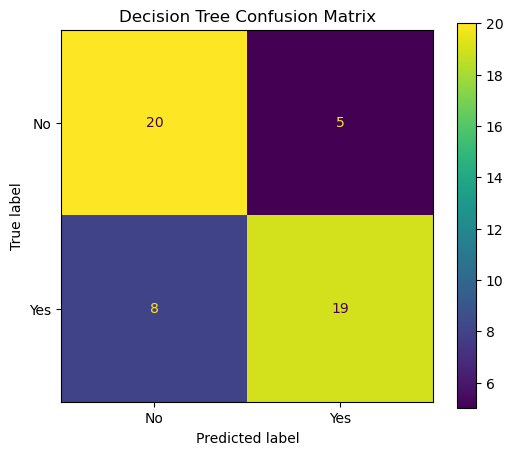

In [115]:
# Create a figure for the confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

# Create a confusion matrix display object
disp = ConfusionMatrixDisplay(
    
    # Use the Decision Tree confusion matrix
    confusion_matrix=cm_dt,
    
    # Use class labels for display
    display_labels=class_labels
)

# Plot the confusion matrix
disp.plot(ax=ax, values_format="d")

# Add a title to the figure
plt.title("Decision Tree Confusion Matrix")

# Display the figure
plt.show()

In [116]:
# Extract values from the confusion matrix
tn, fp, fn, tp = cm_dt.ravel()

# Print True Negative value
print("True Negative:", tn)

# Print False Positive value
print("False Positive:", fp)

# Print False Negative value
print("False Negative:", fn)

# Print True Positive value
print("True Positive:", tp)

True Negative: 20
False Positive: 5
False Negative: 8
True Positive: 19


In [117]:
# Create a table to explain each part of the confusion matrix
confusion_explanation = pd.DataFrame({
    
    # Name of each confusion matrix component
    "Component": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    
    # Meaning of each component in this business problem
    "Meaning": [
        "Lead did not become a won deal, and the model predicted No",
        "Lead did not become a won deal, but the model predicted Yes",
        "Lead became a won deal, but the model predicted No",
        "Lead became a won deal, and the model predicted Yes"
    ],

     # Business impact of each prediction result
    "Business Impact": [
        "The sales team correctly avoided prioritizing a low-potential lead.",
        "The sales team may waste time and resources on a lead unlikely to convert.",
        "The business may miss a valuable sales opportunity or lose the lead to a competitor.",
        "The sales team correctly prioritized a high-potential lead for follow-up."
    ],
    
    # Store the calculated values
    "Value": [tn, fp, fn, tp]
})

# Display the explanation table
display(confusion_explanation)

,Component,Meaning,Business Impact,Value
0,True Negative,"Lead did not become a won deal, and the model ...",The sales team correctly avoided prioritizing ...,20
1,False Positive,"Lead did not become a won deal, but the model ...",The sales team may waste time and resources on...,5
2,False Negative,"Lead became a won deal, but the model predicte...",The business may miss a valuable sales opportu...,8
3,True Positive,"Lead became a won deal, and the model predicte...",The sales team correctly prioritized a high-po...,19


# Accuracy, Precision, Recall, and F1-Score
In this step, we calculate four important evaluation metrics for the Decision Tree model.

These metrics help us understand model performance more clearly than accuracy alone.

- Accuracy shows the overall percentage of correct predictions.
- Precision measures how many leads predicted as won actually became won deals.
- Recall measures how many actual won deals were correctly identified by the model.
- F1-score combines precision and recall into one balanced score.

In this business problem, these metrics help evaluate how effectively the model identifies leads that are likely to become won deals, supporting better sales prioritization decisions.

In [118]:
# Import accuracy_score to calculate overall correct predictions
from sklearn.metrics import accuracy_score

# Import precision_score to calculate precision
from sklearn.metrics import precision_score

# Import recall_score to calculate recall
from sklearn.metrics import recall_score

# Import f1_score to calculate the F1-score
from sklearn.metrics import f1_score

# Import classification_report to show a full performance summary
from sklearn.metrics import classification_report

In [119]:
# Calculate the accuracy of the Decision Tree model
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# Print the accuracy score
print("Decision Tree Accuracy:")

# Display the accuracy value
print(dt_accuracy)

Decision Tree Accuracy:
0.75


In [120]:
# Calculate precision for the positive class, which is "Yes"
dt_precision = precision_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)

# Print the precision score
print("Decision Tree Precision:")

# Display the precision value
print(dt_precision)

Decision Tree Precision:
0.7916666666666666


In [122]:
# Calculate recall for the positive class, which is "Yes"
dt_recall = recall_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)

# Print the recall score
print("Decision Tree Recall:")

# Display the recall value
print(dt_recall)

Decision Tree Recall:
0.7037037037037037


In [123]:
# Calculate F1-score for the positive class, which is "Yes"
dt_f1 = f1_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)

# Print the F1-score
print("Decision Tree F1-Score:")

# Display the F1-score value
print(dt_f1)

Decision Tree F1-Score:
0.7450980392156863


In [140]:
# Create a DataFrame to summarize the Decision Tree evaluation metrics
dt_metrics_table = pd.DataFrame({
    
    # Store the metric names
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    
    # Store the metric values
    "Score": [dt_accuracy, dt_precision, dt_recall, dt_f1]
})

# Display the metrics summary table
display(dt_metrics_table)

,Metric,Score
0,Accuracy,0.750000
1,Precision,0.791667
2,Recall,0.703704
3,F1-Score,0.745098


In [141]:
# Print a title for the classification report
print("Decision Tree Classification Report")

# Print a separator line
print("-" * 50)

# Display the classification report for both classes
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

          No       0.71      0.80      0.75        25
         Yes       0.79      0.70      0.75        27

    accuracy                           0.75        52
   macro avg       0.75      0.75      0.75        52
weighted avg       0.75      0.75      0.75        52



# Understanding Overfitting in Decision Trees
Overfitting happens when a machine learning model learns the training data too well.

In a Decision Tree, overfitting can happen when the tree becomes too deep and creates too many rules.

When this happens, the model may perform very well on the training data but poorly on the testing data.

This means the model memorizes the training data instead of learning general patterns.

In this step, we compare a controlled Decision Tree with an overfitted Decision Tree.

In [126]:
# Import DecisionTreeClassifier from scikit-learn
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree model without limiting max_depth
overfit_tree_model = DecisionTreeClassifier(
    
    # Allow the tree to grow as much as possible
    max_depth=None,
    
    # Use a fixed random state to make the result reproducible
    random_state=42
)

# Train the overfitted Decision Tree model using the processed training data
overfit_tree_model.fit(X_train_processed_df, y_train)

# Print a message to confirm that the model has been trained
print("Overfitted Decision Tree model has been trained.")

Overfitted Decision Tree model has been trained.


In [127]:
# Predict the target values for the training data using the overfitted tree
y_train_pred_overfit = overfit_tree_model.predict(X_train_processed_df)

# Predict the target values for the testing data using the overfitted tree
y_test_pred_overfit = overfit_tree_model.predict(X_test_processed_df)

# Calculate training accuracy for the overfitted tree
overfit_train_accuracy = accuracy_score(y_train, y_train_pred_overfit)

# Calculate testing accuracy for the overfitted tree
overfit_test_accuracy = accuracy_score(y_test, y_test_pred_overfit)

# Print the training accuracy
print("Overfitted Tree Training Accuracy:", overfit_train_accuracy)

# Print the testing accuracy
print("Overfitted Tree Testing Accuracy:", overfit_test_accuracy)

Overfitted Tree Training Accuracy: 1.0
Overfitted Tree Testing Accuracy: 0.6923076923076923


In [128]:
# Predict the target values for the training data using the controlled Decision Tree
y_train_pred_controlled = decision_tree_model.predict(X_train_processed_df)

# Predict the target values for the testing data using the controlled Decision Tree
y_test_pred_controlled = decision_tree_model.predict(X_test_processed_df)

# Calculate training accuracy for the controlled Decision Tree
controlled_train_accuracy = accuracy_score(y_train, y_train_pred_controlled)

# Calculate testing accuracy for the controlled Decision Tree
controlled_test_accuracy = accuracy_score(y_test, y_test_pred_controlled)

# Create a comparison table for both models
overfitting_comparison = pd.DataFrame({
    
    # Store the model names
    "Model": ["Controlled Decision Tree", "Overfitted Decision Tree"],
    
    # Store the training accuracy values
    "Training Accuracy": [controlled_train_accuracy, overfit_train_accuracy],
    
    # Store the testing accuracy values
    "Testing Accuracy": [controlled_test_accuracy, overfit_test_accuracy]
})

# Display the comparison table
display(overfitting_comparison)

,Model,Training Accuracy,Testing Accuracy
0,Controlled Decision Tree,0.894231,0.750000
1,Overfitted Decision Tree,1.000000,0.692308


<Figure size 800x500 with 0 Axes>

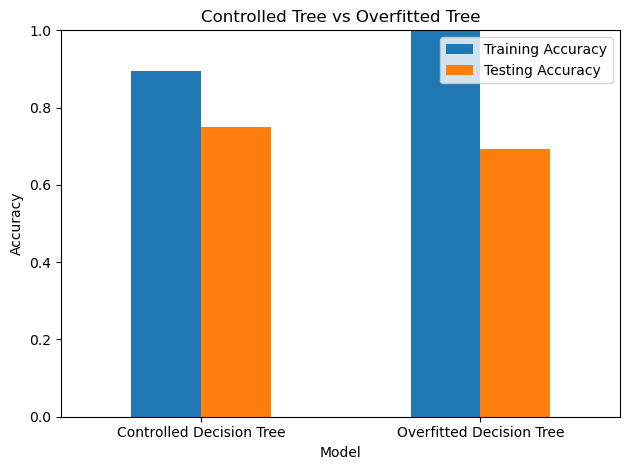

In [129]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Set the model column as the index for better plotting
overfitting_comparison_plot = overfitting_comparison.set_index("Model")

# Create a figure for the comparison chart
plt.figure(figsize=(8, 5))

# Create a bar chart for training and testing accuracy
overfitting_comparison_plot.plot(kind="bar")

# Add a title to the chart
plt.title("Controlled Tree vs Overfitted Tree")

# Add a label to the y-axis
plt.ylabel("Accuracy")

# Set the y-axis range from 0 to 1
plt.ylim(0, 1)

# Rotate x-axis labels for better readability
plt.xticks(rotation=0)

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the chart
plt.show()

In [130]:
# Get the depth of the controlled Decision Tree
controlled_tree_depth = decision_tree_model.get_depth()

# Get the number of leaf nodes in the controlled Decision Tree
controlled_tree_leaves = decision_tree_model.get_n_leaves()

# Get the depth of the overfitted Decision Tree
overfit_tree_depth = overfit_tree_model.get_depth()

# Get the number of leaf nodes in the overfitted Decision Tree
overfit_tree_leaves = overfit_tree_model.get_n_leaves()

# Create a table to compare tree complexity
tree_complexity_table = pd.DataFrame({
    
    # Store the model names
    "Model": ["Controlled Decision Tree", "Overfitted Decision Tree"],
    
    # Store tree depth values
    "Tree Depth": [controlled_tree_depth, overfit_tree_depth],
    
    # Store number of leaf nodes
    "Number of Leaves": [controlled_tree_leaves, overfit_tree_leaves]
})

# Display the tree complexity table
display(tree_complexity_table)

,Model,Tree Depth,Number of Leaves
0,Controlled Decision Tree,4,14
1,Overfitted Decision Tree,10,35


# Controlling Decision Tree Complexity
Decision Trees can become too complex if they are allowed to grow without limits.

A very deep tree may memorize the training data instead of learning general patterns.

To reduce overfitting, we can control the complexity of the Decision Tree using parameters such as:

- max_depth
- min_samples_split
- min_samples_leaf

In this step, we compare Decision Trees with different maximum depths and observe how training and testing accuracy change.

In [131]:
# Import DecisionTreeClassifier to create Decision Tree models
from sklearn.tree import DecisionTreeClassifier

# Import accuracy_score to calculate model accuracy
from sklearn.metrics import accuracy_score

# Import pandas to create comparison tables
import pandas as pd

# Import matplotlib to create charts
import matplotlib.pyplot as plt

In [132]:
# Create an empty list to store the results
depth_results = []

# Create a list of different max_depth values to test
depth_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Loop through each depth value
for depth in depth_values:
    
    # Create a Decision Tree model with the current max_depth
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    # Train the model using the processed training data
    model.fit(X_train_processed_df, y_train)
    
    # Predict the target values for the training data
    y_train_pred = model.predict(X_train_processed_df)
    
    # Predict the target values for the testing data
    y_test_pred = model.predict(X_test_processed_df)
    
    # Calculate training accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    
    # Calculate testing accuracy
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # Store the depth, training accuracy, and testing accuracy
    depth_results.append([depth, train_accuracy, test_accuracy])

# Convert the results into a DataFrame
depth_results_df = pd.DataFrame(
    depth_results,
    columns=["Max Depth", "Training Accuracy", "Testing Accuracy"]
)

# Display the results table
display(depth_results_df)

,Max Depth,Training Accuracy,Testing Accuracy
0,1,0.817308,0.826923
1,2,0.831731,0.826923
2,3,0.865385,0.750000
3,4,0.894231,0.750000
4,5,0.923077,0.750000
5,6,0.937500,0.769231
6,7,0.956731,0.711538
7,8,0.971154,0.750000
8,9,0.990385,0.711538
9,10,1.000000,0.692308


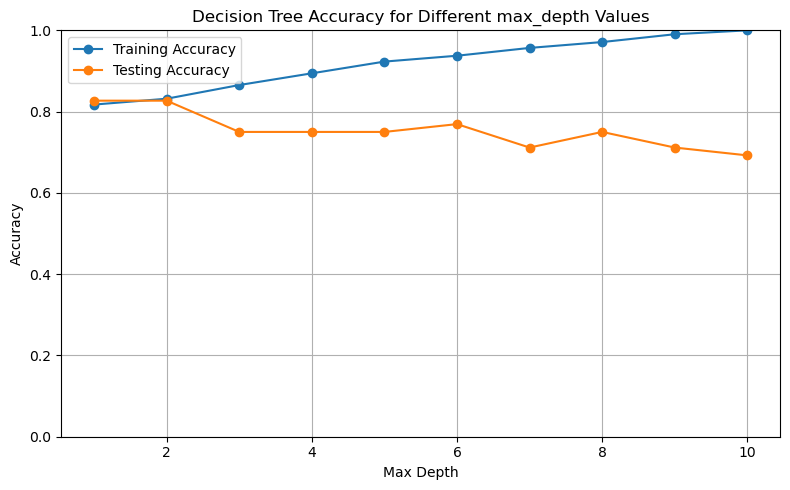

In [133]:
# Create a figure for the line chart
plt.figure(figsize=(8, 5))

# Plot training accuracy for each max_depth value
plt.plot(depth_results_df["Max Depth"], depth_results_df["Training Accuracy"], marker="o", label="Training Accuracy")

# Plot testing accuracy for each max_depth value
plt.plot(depth_results_df["Max Depth"], depth_results_df["Testing Accuracy"], marker="o", label="Testing Accuracy")

# Add a title to the chart
plt.title("Decision Tree Accuracy for Different max_depth Values")

# Add a label to the x-axis
plt.xlabel("Max Depth")

# Add a label to the y-axis
plt.ylabel("Accuracy")

# Set the y-axis range from 0 to 1
plt.ylim(0, 1)

# Add a legend to explain the lines
plt.legend()

# Add grid lines to make the chart easier to read
plt.grid(True)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [134]:
# Create a controlled Decision Tree model
controlled_tree_model = DecisionTreeClassifier(
    
    # Limit the maximum depth of the tree
    max_depth=4,
    
    # Require at least 5 samples in each leaf node
    min_samples_leaf=5,
    
    # Use a fixed random state for reproducible results
    random_state=42
)

# Train the controlled Decision Tree model
controlled_tree_model.fit(X_train_processed_df, y_train)

# Print a message to confirm that the controlled model has been trained
print("Controlled Decision Tree model has been trained successfully.")

Controlled Decision Tree model has been trained successfully.


In [135]:
# Predict the target values for the training data
y_train_pred_controlled = controlled_tree_model.predict(X_train_processed_df)

# Predict the target values for the testing data
y_test_pred_controlled = controlled_tree_model.predict(X_test_processed_df)

# Calculate training accuracy for the controlled tree
controlled_train_accuracy = accuracy_score(y_train, y_train_pred_controlled)

# Calculate testing accuracy for the controlled tree
controlled_test_accuracy = accuracy_score(y_test, y_test_pred_controlled)

# Print the training accuracy
print("Controlled Decision Tree Training Accuracy:", controlled_train_accuracy)

# Print the testing accuracy
print("Controlled Decision Tree Testing Accuracy:", controlled_test_accuracy)

Controlled Decision Tree Training Accuracy: 0.8653846153846154
Controlled Decision Tree Testing Accuracy: 0.75


In [136]:
# Calculate training accuracy for the original Decision Tree model
original_train_accuracy = accuracy_score(y_train, decision_tree_model.predict(X_train_processed_df))

# Calculate testing accuracy for the original Decision Tree model
original_test_accuracy = accuracy_score(y_test, decision_tree_model.predict(X_test_processed_df))

# Create a comparison table
tree_control_comparison = pd.DataFrame({
    
    # Store model names
    "Model": ["Original Decision Tree", "Controlled Decision Tree"],
    
    # Store training accuracy values
    "Training Accuracy": [original_train_accuracy, controlled_train_accuracy],
    
    # Store testing accuracy values
    "Testing Accuracy": [original_test_accuracy, controlled_test_accuracy]
})

# Display the comparison table
display(tree_control_comparison)

,Model,Training Accuracy,Testing Accuracy
0,Original Decision Tree,0.894231,0.75
1,Controlled Decision Tree,0.865385,0.75


<Figure size 800x500 with 0 Axes>

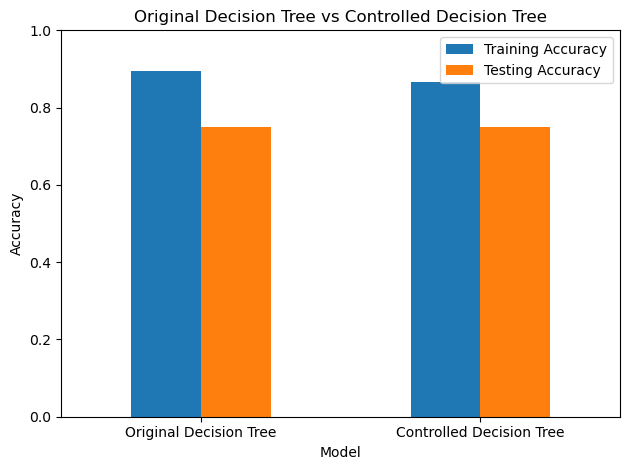

In [137]:
# Set the model column as the index for plotting
tree_control_plot = tree_control_comparison.set_index("Model")

# Create a figure for the comparison chart
plt.figure(figsize=(8, 5))

# Create a bar chart for training and testing accuracy
tree_control_plot.plot(kind="bar")

# Add a title to the chart
plt.title("Original Decision Tree vs Controlled Decision Tree")

# Add a label to the y-axis
plt.ylabel("Accuracy")

# Set the y-axis range from 0 to 1
plt.ylim(0, 1)

# Rotate x-axis labels to keep them readable
plt.xticks(rotation=0)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [138]:
# Get the depth of the original Decision Tree
original_depth = decision_tree_model.get_depth()

# Get the number of leaves in the original Decision Tree
original_leaves = decision_tree_model.get_n_leaves()

# Get the depth of the controlled Decision Tree
controlled_depth = controlled_tree_model.get_depth()

# Get the number of leaves in the controlled Decision Tree
controlled_leaves = controlled_tree_model.get_n_leaves()

# Create a table to compare tree complexity
complexity_comparison = pd.DataFrame({
    
    # Store model names
    "Model": ["Original Decision Tree", "Controlled Decision Tree"],
    
    # Store tree depth values
    "Tree Depth": [original_depth, controlled_depth],
    
    # Store number of leaves
    "Number of Leaves": [original_leaves, controlled_leaves]
})

# Display the complexity comparison table
display(complexity_comparison)

,Model,Tree Depth,Number of Leaves
0,Original Decision Tree,4,14
1,Controlled Decision Tree,4,12


# Feature Importance in Tree-Based Models
Tree-based models can show which features are most important for making predictions.

Feature importance helps us understand which variables had the strongest influence on the model's decision.

In this business problem, feature importance helps identify which lead characteristics and behaviors are most associated with winning a deal

For example, important features may include website visits, email open rate, demo requests, sales calls, discount offered, and deal value.

In this step, we calculate feature importance for the Decision Tree model.

In [142]:
# Print a title for the output
print("Processed Feature Names")

# Print a separator line
print("-" * 50)

# Show the number of processed features after one-hot encoding
print("Number of processed features:", len(X_train_processed_df.columns))

# Display the processed feature names
print(X_train_processed_df.columns.tolist())

Processed Feature Names
--------------------------------------------------
Number of processed features: 54
['Lead_Source_Email Campaign', 'Lead_Source_Google Search', 'Lead_Source_LinkedIn Ads', 'Lead_Source_Organic Website', 'Lead_Source_Referral', 'Lead_Source_Trade Show', 'Lead_Source_Webinar', 'Industry_Education', 'Industry_Finance', 'Industry_Healthcare', 'Industry_Hospitality', 'Industry_Manufacturing', 'Industry_Professional Services', 'Industry_Retail', 'Industry_Technology', 'Region_Alberta', 'Region_Atlantic Canada', 'Region_British Columbia', 'Region_Ontario', 'Region_Prairies', 'Region_Quebec', 'Company_Size_Enterprise', 'Company_Size_Large', 'Company_Size_Medium', 'Company_Size_Small', 'Use_Case_CRM Automation', 'Use_Case_Customer Analytics', 'Use_Case_Marketing Automation', 'Use_Case_Sales Forecasting', 'Use_Case_Workflow Automation', 'Demo_Requested_No', 'Demo_Requested_Yes', 'Proposal_Sent_No', 'Proposal_Sent_Yes', 'Budget_Confirmed_No', 'Budget_Confirmed_Yes', 'Decis

In [143]:
# Get feature importance values from the trained Decision Tree model
dt_feature_importance_values = decision_tree_model.feature_importances_

# Create a DataFrame for Decision Tree feature importance
dt_feature_importance = pd.DataFrame({
    
    # Store feature names
    "Feature": X_train_processed_df.columns,
    
    # Store Decision Tree importance values
    "Importance": dt_feature_importance_values
})

# Sort the features from most important to least important
dt_feature_importance = dt_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Reset the index after sorting
dt_feature_importance = dt_feature_importance.reset_index(drop=True)

# Print a title for the output
print("Decision Tree Feature Importance")

# Display the top 10 most important features
display(dt_feature_importance.head(10))

Decision Tree Feature Importance


,Feature,Importance
0,Lead_Score,0.655025
1,Estimated_Deal_Value,0.129973
2,Days_In_Pipeline,0.110215
3,Lead_Source_Referral,0.036809
4,Industry_Hospitality,0.027762
5,Discount_Offered_Percent,0.023175
6,Lead_Source_LinkedIn Ads,0.017041
7,Budget_Confirmed_Yes,0.000000
8,Competitor_Considered_No,0.000000
9,Decision_Maker_Involved_Yes,0.000000


In [144]:
# Select the most important feature from the Decision Tree model
dt_most_important_feature = dt_feature_importance.iloc[0]["Feature"]

# Select the importance value of the most important Decision Tree feature
dt_most_important_value = dt_feature_importance.iloc[0]["Importance"]

# Print the most important Decision Tree feature
print("Most important feature in Decision Tree:", dt_most_important_feature)

# Print its importance value
print("Decision Tree importance value:", dt_most_important_value)


Most important feature in Decision Tree: Lead_Score
Decision Tree importance value: 0.6550248798061631


In [145]:
# Create a short summary table for feature importance results
feature_importance_summary = pd.DataFrame({
    
    # Store model names
    "Model": ["Decision Tree"],
    
    # Store the most important feature for each model
    "Most Important Feature": [dt_most_important_feature],
    
    # Store the importance value for each model
    "Importance Value": [dt_most_important_value]
})

# Display the summary table
display(feature_importance_summary)

,Model,Most Important Feature,Importance Value
0,Decision Tree,Lead_Score,0.655025


# Visualizing Feature Importance
In this step, we visualize the most important features used by the Decision Tree model.

A higher importance score means that the feature contributed more to the model's decision-making process.

This step is useful for both model interpretation and business decision-making.

In [146]:
# Select the top 10 most important features from the Decision Tree model
dt_top_features = dt_feature_importance.head(10)

# Print a title for the output
print("Top 10 Decision Tree Features")

# Print a separator line
print("-" * 50)

# Display the top 10 Decision Tree features
display(dt_top_features)

Top 10 Decision Tree Features
--------------------------------------------------


,Feature,Importance
0,Lead_Score,0.655025
1,Estimated_Deal_Value,0.129973
2,Days_In_Pipeline,0.110215
3,Lead_Source_Referral,0.036809
4,Industry_Hospitality,0.027762
5,Discount_Offered_Percent,0.023175
6,Lead_Source_LinkedIn Ads,0.017041
7,Budget_Confirmed_Yes,0.000000
8,Competitor_Considered_No,0.000000
9,Decision_Maker_Involved_Yes,0.000000


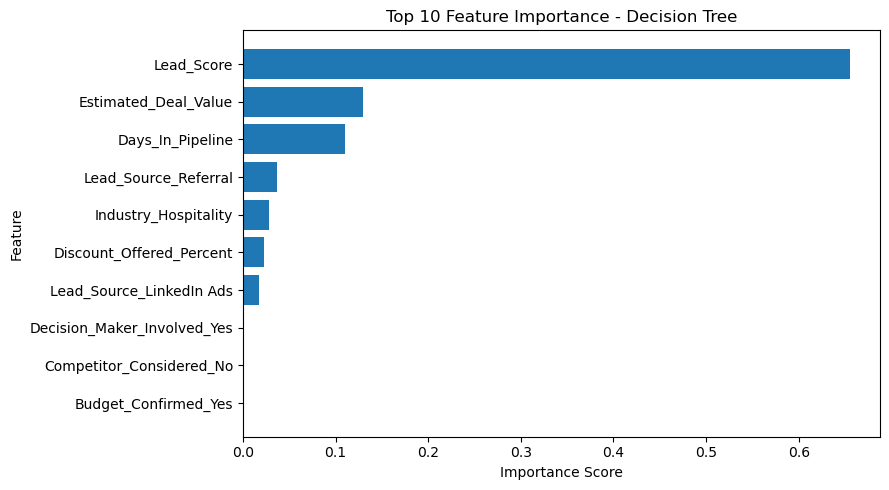

In [147]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Sort the top Decision Tree features in ascending order for better horizontal visualization
dt_top_features_plot = dt_top_features.sort_values(by="Importance", ascending=True)

# Create a figure for the Decision Tree feature importance chart
plt.figure(figsize=(9, 5))

# Create a horizontal bar chart for Decision Tree feature importance
plt.barh(dt_top_features_plot["Feature"], dt_top_features_plot["Importance"])

# Add a title to the chart
plt.title("Top 10 Feature Importance - Decision Tree")

# Add a label to the x-axis
plt.xlabel("Importance Score")

# Add a label to the y-axis
plt.ylabel("Feature")

# Adjust the layout to prevent labels from being cut off
plt.tight_layout()

# Display the chart
plt.show()